# Idea 2: Semantic Arithmetic

**Do geo embeddings support vector arithmetic text embeddings, e.g. $king - man + woman = queen$?**

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from datasets import load_dataset
from collections import defaultdict

sys.path.insert(0, ".")
from utils import load_embedding_cache, msi_to_rgb, SEED, N_PER_CLASS

In [2]:
os.makedirs("../data", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

ds = load_dataset("blanchon/EuroSAT_MSI", split="train")
class_names = ds.features["label"].names
print(f"Classes: {class_names}")

all_labels_list = ds["label"]
idx_by_class = defaultdict(list)
for i, lbl in enumerate(all_labels_list):
    idx_by_class[lbl].append(i)

rng = np.random.default_rng(SEED)
selected = []
for cls in range(len(class_names)):
    n = min(N_PER_CLASS, len(idx_by_class[cls]))
    selected.extend(rng.choice(idx_by_class[cls], n, replace=False).tolist())

subset = ds.select(selected)
labels = np.array(subset["label"], dtype=np.int64)
images = [np.array(img) for img in subset["image"]] # [H, W, 13] uint16, matches cache order
N = len(labels)
print(f"Loaded {N} images ({N_PER_CLASS} x {len(class_names)} classes)")

Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']
Loaded 10000 images (1000 x 10 classes)


In [3]:
# Load Clay Embeddings

emb_cache = "../data/nb01_clay_emb_msi.pt"
expected_n = N_PER_CLASS * len(class_names)

if not os.path.exists(emb_cache):
    raise FileNotFoundError(f"Run notebook 01 first to generate {emb_cache}")

clay_emb, labels, class_names = load_embedding_cache(emb_cache)

print(f"Loaded cache: {clay_emb.shape}")

Loaded cache: (10000, 1024)
Loaded cache: (10000, 1024)


## Class Centroids and Semantic Directions

A *semantic direction* is the vector from the mean of one class to another.
Adding this vector to an embedding should shift it toward the target class.

In [4]:
# Compute mean embedding per class (centroid)
centroids = np.array([
    clay_emb[labels == c].mean(axis=0)
    for c in range(len(class_names))
])
print(f"Centroids: {centroids.shape} (one per class, 1024-dim)")
print(f"Classes: {class_names}")

# Named class index lookup
class_name_to_idx = {name: i for i, name in enumerate(class_names)}

# Compute some semantic direction vectors: vectors pointing from class A to class B in embedding space = centroids[B] - centroids[A]
directions = {
    "forest -> residential built": centroids[class_name_to_idx["Residential Buildings"]] - centroids[class_name_to_idx["Forest"]],
    "industrial built -> residential built": centroids[class_name_to_idx["Residential Buildings"]] - centroids[class_name_to_idx["Industrial Buildings"]],
    "highway -> river": centroids[class_name_to_idx["River"]] - centroids[class_name_to_idx["Highway"]],
    "highway -> vegetation": centroids[class_name_to_idx["Herbaceous Vegetation"]] - centroids[class_name_to_idx["Highway"]],
    "annual crop -> water": centroids[class_name_to_idx["SeaLake"]] - centroids[class_name_to_idx["Annual Crop"]],
    "forest -> residential built": centroids[class_name_to_idx["Residential Buildings"]] - centroids[class_name_to_idx["Forest"]],
    "pasture -> industrial built": centroids[class_name_to_idx["Industrial Buildings"]] - centroids[class_name_to_idx["Pasture"]],
    "pasture -> annual crop": centroids[class_name_to_idx["Annual Crop"]] - centroids[class_name_to_idx["Pasture"]],
    "forest -> water": centroids[class_name_to_idx["SeaLake"]] - centroids[class_name_to_idx["Forest"]],
}

# Measuring the strength of the direction by computing hte norm (length of the direction vector)
print("")
for name, vec in directions.items():
    print(f"{name}: norm={np.linalg.norm(vec):.2f}")

Centroids: (10, 1024) (one per class, 1024-dim)
Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']

forest -> residential built: norm=1.76
industrial built -> residential built: norm=1.02
highway -> river: norm=0.98
highway -> vegetation: norm=0.86
annual crop -> water: norm=2.54
pasture -> industrial built: norm=1.95
pasture -> annual crop: norm=1.37
forest -> water: norm=2.38


## Directional Shift Test

For each direction **$d = \text{mean}(B) - \text{mean}(A)$**, take individual tiles from class $A$, add $d$, and check what fraction of nearest neighbours land in class $B$.

This measures whether the centroid direction is consistent across individual tiles, but it is **not** the king−man+woman=queen test: the direction is computed from A and B, then applied back to A, so landing near B is expected by construction.

In [ ]:
def analogy_test(
    emb: np.ndarray,
    labels: np.ndarray,
    src_cls: int,
    tgt_cls: int,
    direction: np.ndarray,
    k: int = 5,
) -> np.ndarray:
    """
    For each tile of src_cls: add direction, find top-k neighbors.
    Returns per-tile fraction of neighbors in tgt_cls.
    """
    E = normalize(emb.astype(np.float32))
    src_idx = np.where(labels == src_cls)[0]
    results = []
    for i in src_idx:
        query = emb[i] + direction
        query = query / (np.linalg.norm(query) + 1e-8)
        sims = query @ E.T
        sims[i] = -np.inf
        nn = np.argsort(sims)[-k:]
        results.append(np.mean(labels[nn] == tgt_cls))
    return np.array(results)


tests = [
    ("Forest", "Residential Buildings"),
    ("Pasture", "Industrial Buildings"),
    ("Annual Crop", "SeaLake"),
    ("Highway", "River"),
    ("Residential Buildings","Forest"), # reverse
    ("Industrial Buildings", "Pasture"), # reverse
]

E_norm = normalize(clay_emb.astype(np.float32))
sims_all = E_norm @ E_norm.T
np.fill_diagonal(sims_all, -np.inf)

print(f"{'From':>25} -> {'To':<25} {'P@5 (shift)':>12} {'P@5 (baseline)':>15}")
print("-" * 84)

for src_name, tgt_name in tests:
    src, tgt = class_name_to_idx[src_name], class_name_to_idx[tgt_name]
    d = centroids[tgt] - centroids[src]

    shift_scores = analogy_test(clay_emb, labels, src, tgt, d, k=5)

    src_idx = np.where(labels == src)[0]
    base_scores = np.array([
        np.mean(labels[np.argsort(sims_all[i])[-5:]] == tgt)
        for i in src_idx
    ])

    print(f"{src_name:>25} -> {tgt_name:<25} {shift_scores.mean():>12.3f} {base_scores.mean():>15.3f}")


                     From -> To                          P@5 (shift)   P@5 (baseline)
------------------------------------------------------------------------------------
                   Forest -> Residential Buildings             0.698            0.006
                  Pasture -> Industrial Buildings              0.906            0.003
              Annual Crop -> SeaLake                           1.000            0.000
                  Highway -> River                             0.680            0.101
    Residential Buildings -> Forest                            0.819            0.001
     Industrial Buildings -> Pasture                           0.558            0.000


## Term Analogy Test

The term analogy test uses **four distinct concepts**. A direction is learned from two classes, then applied to a **third class** that played no role in computing it:
$$\text{query} = \text{mean}(C) + \text{mean}(B) - \text{mean}(A)$$
The result should land near a semantically coherent fourth class $D$.


In [21]:
def centroid_analogy(a: str, b: str, c: str) -> list[tuple[str, float]]:
    """
    4-term analogy: mean(C) + mean(B) - mean(A) = ? Returns classes ranked by cosine similarity, excluding a, b, c.
    """
    query = centroids[class_name_to_idx[c]] + centroids[class_name_to_idx[b]] - centroids[class_name_to_idx[a]]
    query_norm = query / np.linalg.norm(query)
    cents_norm = normalize(centroids)
    sims = cents_norm @ query_norm
    exclude = {class_name_to_idx[a], class_name_to_idx[b], class_name_to_idx[c]}
    return [
        (class_names[i], float(sims[i]))
        for i in np.argsort(sims)[::-1]
        if i not in exclude
    ]


analogies = [
    ("Highway", "SeaLake", "River"),
    ("Highway", "Residential Buildings", "River"),
]

for a, b, c in analogies:
    print(f"mean({c}) + mean({b}) - mean({a}) = ?")
    ranked = centroid_analogy(a, b, c)
    for rank, (name, sim) in enumerate(ranked, 1):
        print(f"  {rank}. {name:<30} cos={sim:.3f}")
    print()


mean(River) + mean(SeaLake) - mean(Highway) = ?
  1. Forest                         cos=0.690
  2. Industrial Buildings           cos=0.685
  3. Residential Buildings          cos=0.683
  4. Herbaceous Vegetation          cos=0.660
  5. Annual Crop                    cos=0.603
  6. Permanent Crop                 cos=0.579
  7. Pasture                        cos=0.556

mean(River) + mean(Residential Buildings) - mean(Highway) = ?
  1. Industrial Buildings           cos=0.927
  2. Herbaceous Vegetation          cos=0.915
  3. Permanent Crop                 cos=0.861
  4. Forest                         cos=0.860
  5. SeaLake                        cos=0.850
  6. Annual Crop                    cos=0.831
  7. Pasture                        cos=0.806



## PCA Visualization with Semantic Direction Arrows

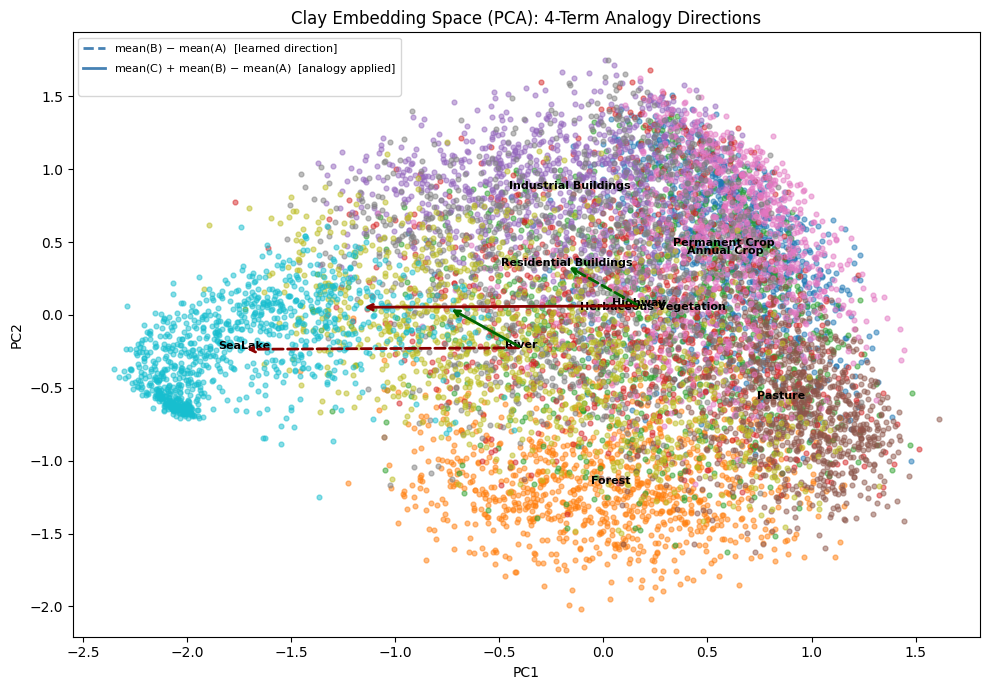

In [23]:
pca = PCA(n_components=2, random_state=SEED)
emb2d = pca.fit_transform(clay_emb)
cents2d = pca.transform(centroids)

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.get_cmap("tab10")

for c in range(len(class_names)):
    m = labels == c
    ax.scatter(emb2d[m, 0], emb2d[m, 1], color=cmap(c), s=12, alpha=0.5)
    ax.annotate(class_names[c], cents2d[c], fontsize=8, fontweight="bold", color="black", ha="center")

# Each analogy (A, B, C, color):
# - dashed arrow A -> B: the direction being learned
# - solidarrow C -> C + (B - A): the same direction applied to C
analogy_arrows = [
    ("River", "SeaLake", "Highway", "darkred"),
    ("Highway", "Residential Buildings", "River","darkgreen"),
    # ("River", "Residential Buildings", "Highway","darkorange"),
]

arrow_kw = dict(arrowstyle="->", lw=2)
for a, b, c, color in analogy_arrows:
    sa, sb, sc = cents2d[class_name_to_idx[a]], cents2d[class_name_to_idx[b]], cents2d[class_name_to_idx[c]]
    d2 = sb - sa # direction in PCA space

    # dashed: learned direction A -> B
    ax.annotate("", xy=sb, xytext=sa, arrowprops=dict(**arrow_kw, color=color, linestyle="dashed"))

    # solid: direction applied to C  (C -> C + d)
    ax.annotate("", xy=sc + d2, xytext=sc, arrowprops=dict(**arrow_kw, color=color))

# Legend for arrow styles
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="steelblue", lw=2, linestyle="--", label=r"mean(B) $-$ mean(A)  [learned direction]"),
    Line2D([0], [0], color="steelblue", lw=2, label=r"mean(C) $+$ mean(B) $-$ mean(A)  [analogy applied]"),
    Line2D([0], [0], color="steelblue", lw=4, alpha=0, label=""),
]
ax.legend(handles=legend_elements, fontsize=8, loc="upper left")

ax.set_title("Clay Embedding Space (PCA): 4-Term Analogy Directions")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("../figures/02_semantic_directions.png", dpi=150, bbox_inches="tight")
plt.show()


Doesn't work well. This is not surproising since we used the labels as proxy for semantics, but the labels where very limited. River + Residential Buildings - Highway, makes somewhat sense since it points between SeaLake and Industrial/Residential Buildings. We would expect it to point towards SeaLake. Another limitation here is the dimensionality reduction with PCA.

## Interpolation: Path Between Two Classes

Visualise latent-space walk from one class centroid to another class centroid: at each point along that path retrieve the real tile whose embedding is closest.

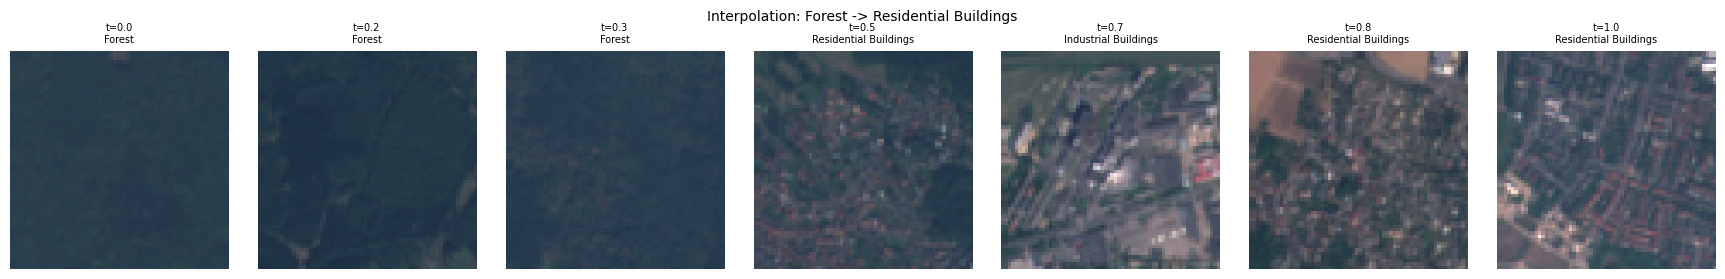

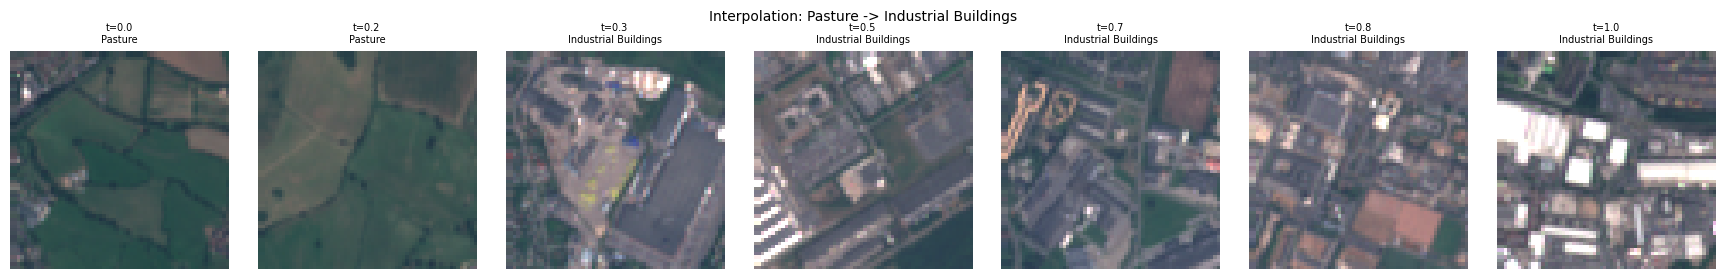

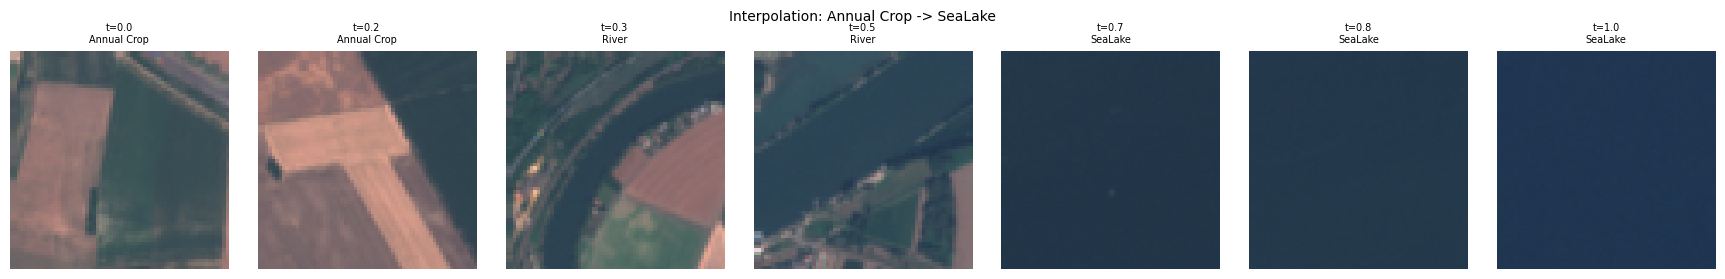

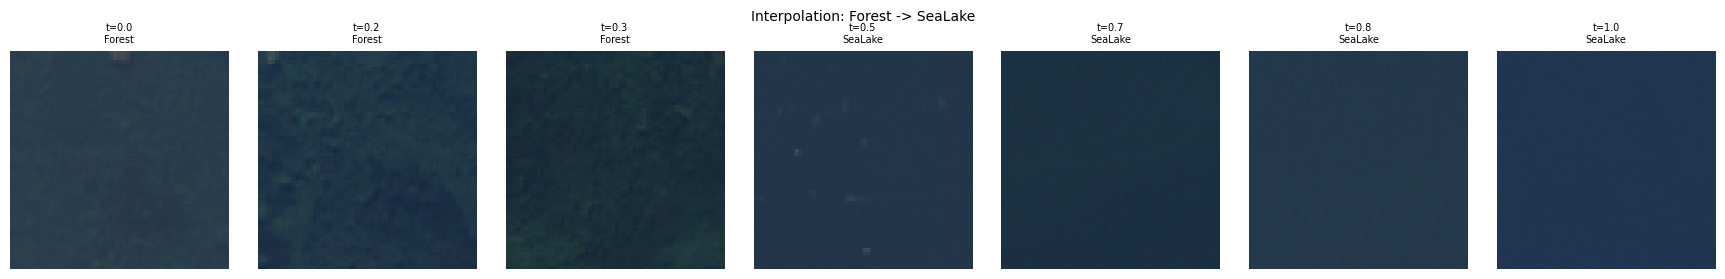

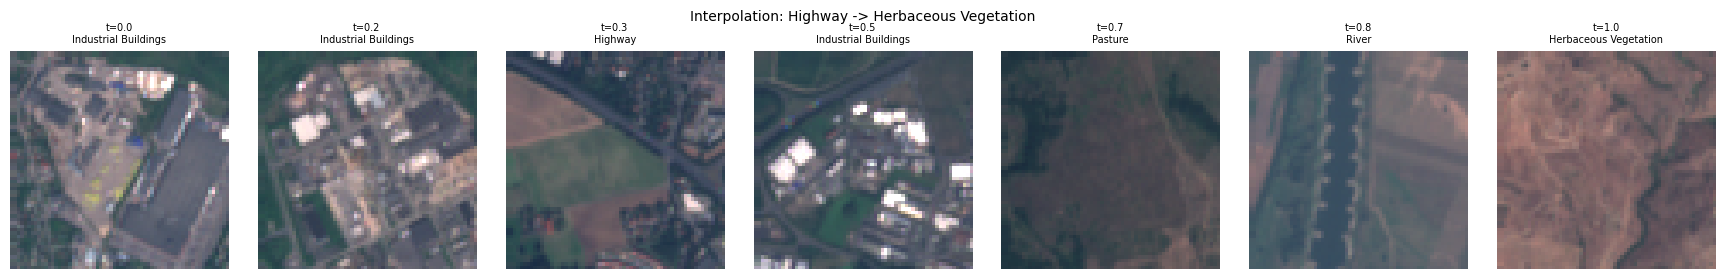

In [8]:
# Interpolate between Forest and Residential centroids. At each step, find the nearest tile and visualise it.

def latent_space_walk(src_name: str, tgt_name: str):
    src_c = class_name_to_idx[src_name]
    tgt_c = class_name_to_idx[tgt_name]
    n_steps = 7

    E_norm = normalize(clay_emb.astype(np.float32))

    fig, axes = plt.subplots(1, n_steps, figsize=(2.5 * n_steps, 2.8))
    used = set()

    for step, t in enumerate(np.linspace(0, 1, n_steps)):
        query = (1 - t) * centroids[src_c] + t * centroids[tgt_c]
        query_norm = query / (np.linalg.norm(query) + 1e-8)
        sims = query_norm @ E_norm.T
        for j in np.argsort(sims)[::-1]:
            if j not in used:
                used.add(j)
                break
        arr = images[j]
        rgb = msi_to_rgb(arr if arr.shape[0] == 13 else arr.transpose(2, 0, 1))
        axes[step].imshow(rgb)
        axes[step].axis("off")
        axes[step].set_title(f"t={t:.1f}\n{class_names[labels[j]]}", fontsize=7)

    plt.suptitle(f"Interpolation: {src_name} -> {tgt_name}", fontsize=10)
    plt.tight_layout()
    plt.show()

latent_space_walk(src_name="Forest", tgt_name="Residential Buildings")
latent_space_walk(src_name="Pasture", tgt_name="Industrial Buildings")
latent_space_walk(src_name="Annual Crop", tgt_name="SeaLake")
latent_space_walk(src_name="Forest", tgt_name="SeaLake")
latent_space_walk(src_name="Highway", tgt_name="Herbaceous Vegetation")
